## Importing Resources

In [2]:
import json
import logging
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub
import tf_keras

ModuleNotFoundError: No module named 'PIL'

## Load the Dataset

In [ ]:
dataset, dataset_info = tfds.load('oxford_flowers102', as_supervised=True, with_info=True)
training_set = dataset['train']
validation_set = dataset['validation']
test_set = dataset['test']

NameError: name 'tfds' is not defined

## Exploring the Dataset

In [ ]:
num_training_examples = dataset_info.splits['train'].num_examples
num_validation_examples = dataset_info.splits['validation'].num_examples
num_test_examples = dataset_info.splits['test'].num_examples

print(f"Number of training examples: {num_training_examples}")
print(f"Number of validation examples: {num_validation_examples}")
print(f"Number of test examples: {num_test_examples}")
num_classes = dataset_info.features['label'].num_classes

print(f"Number of classes: {num_classes}")

Number of training examples: 1020
Number of validation examples: 1020
Number of test examples: 6149
Number of classes: 102


In [ ]:
for image, label in training_set.take(3):
    print(f"Image shape: {image.shape}, Label: {label.numpy()}")

Image shape: (500, 667, 3), Label: 72
Image shape: (500, 666, 3), Label: 84
Image shape: (670, 500, 3), Label: 70


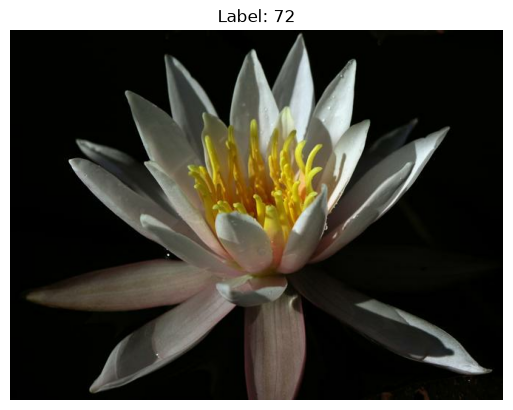

In [ ]:
for image, label in training_set.take(1):
    image = image.numpy()
    plt.imshow(image)
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
    plt.show()

### Label Mapping


In [ ]:
with open('label_map.json', 'r') as f:
    class_names = json.load(f)

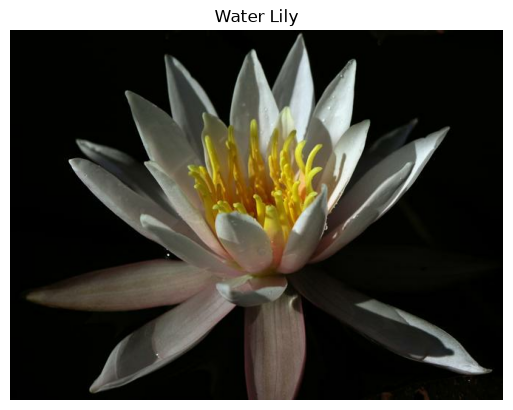

In [ ]:
for image, label in training_set.take(1):
    image = image.numpy()
    plt.imshow(image)
    
    flower_name = class_names[str(label.numpy())]
    plt.title(flower_name.title())
    plt.axis('off')
    plt.show()


## Creating Pipeline

In [ ]:
def format_image(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (224, 224))
    image /= 255.0
    return image, label

batch_size = 32
train_batches = training_set.shuffle(num_training_examples // 4).map(format_image).batch(batch_size).prefetch(1)
validation_batches = validation_set.map(format_image).batch(batch_size).prefetch(1)
test_batches = test_set.map(format_image).batch(batch_size).prefetch(1)


# Building and Training the Classifier

In [ ]:
URL = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
feature_extractor = hub.KerasLayer(URL, input_shape=(224, 224, 3))
feature_extractor.trainable = False


model = tf_keras.Sequential([
    feature_extractor,
    tf_keras.layers.Dense(256, activation='relu'),
    tf_keras.layers.Dropout(0.2),
    tf_keras.layers.Dense(102, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_batches, 
    epochs=10, 
    validation_data=validation_batches
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 102)               26214     
                                                                 
Total params: 2612134 (9.96 MB)
Trainable params: 354150 (1.35 MB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________
Epoch 1/10



32/32 [==============================] - 23s 635ms/step - loss: 4.3891 - accuracy: 0.0902 - val_loss: 3.5862 - val_accuracy: 0.2637
Epoch 2/10
32/32 [==============================] - 19s 608ms/step - loss: 2.6730 - accuracy: 0.4735 - val_loss: 2.1313 - val_accuracy: 0.6049
Epoch 3/10
32/32 [==============================] - 18s 565ms/step - loss: 1.3662 - accuracy: 0.7343 - val_loss: 1.5098 - val_accuracy: 0.6873
Epoch 4/10
32/32 [==============================] - 17s 549ms/step - loss: 0.7914 - accuracy: 0.8402 - val_loss: 1.2419 - val_accuracy: 0.7167
Epoch 5/10
32/32 [==============================] - 17s 525ms/step - loss: 0.4634 - accuracy: 0.9275 - val_loss: 1.0880 - val_accuracy: 0.7284
Epoch 6/10
32/32 [==============================] - 17s 521ms/step - loss: 0.3406 - accuracy: 0.9382 - val_loss: 1.0166 - val_accuracy: 0.7431
Epoch 7/10
32/32 [==============================] - 17s 524ms/step - loss: 0.2378 - accuracy: 0.9706 - val_loss: 0.9078 - val_accuracy: 0.7745
Epoch 8/10

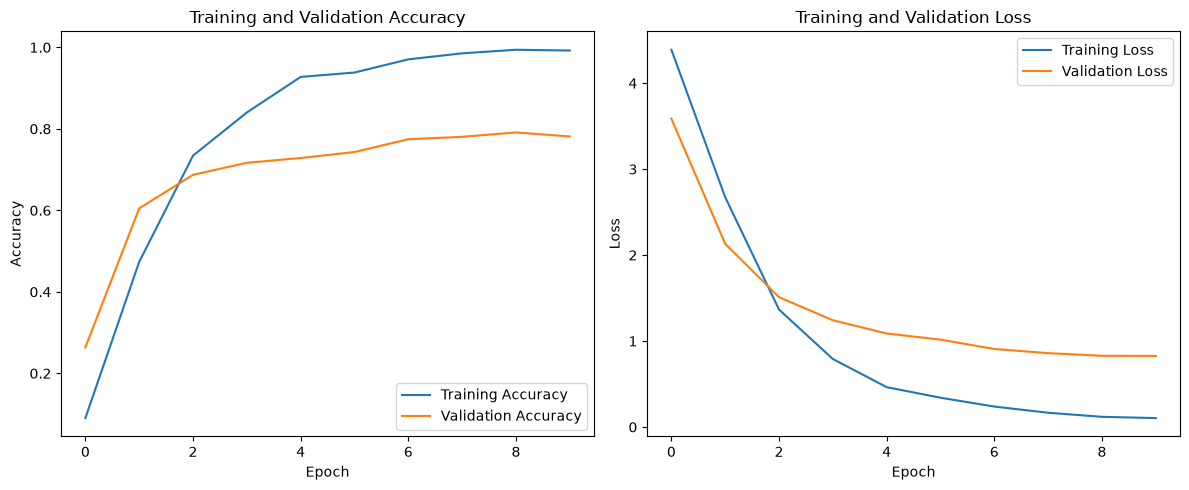

In [ ]:
plt.figure(figsize=(12, 5))

#Accuracy curves
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

#Loss curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


## Testing the Network

In [ ]:
loss, accuracy = model.evaluate(test_batches)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

193/193 [==============================] - 50s 257ms/step - loss: 0.9406 - accuracy: 0.7596

Test Loss: 0.9406
Test Accuracy: 75.96%


## Saving the Model

In [ ]:
model.save('flower_model.h5')
print("Model successfully saved to disk!")

Model successfully saved to disk!


r:\ACC\.venv\Lib\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Loading the Keras Model

In [ ]:
reloaded_model = tf_keras.models.load_model(
    'flower_model.h5', 
    custom_objects={'KerasLayer': hub.KerasLayer}
)

# Inference for Classification

In [ ]:
def process_image(image_np):
    image = tf.convert_to_tensor(image_np, dtype=tf.float32)

    image = tf.image.resize(image, (224, 224))
    
    image /= 255.0
    return image.numpy()

To check the `process_image` function I have provided 4 images in the `./test_images/` folder:

* cautleya_spicata.jpg
* hard-leaved_pocket_orchid.jpg
* orange_dahlia.jpg
* wild_pansy.jpg

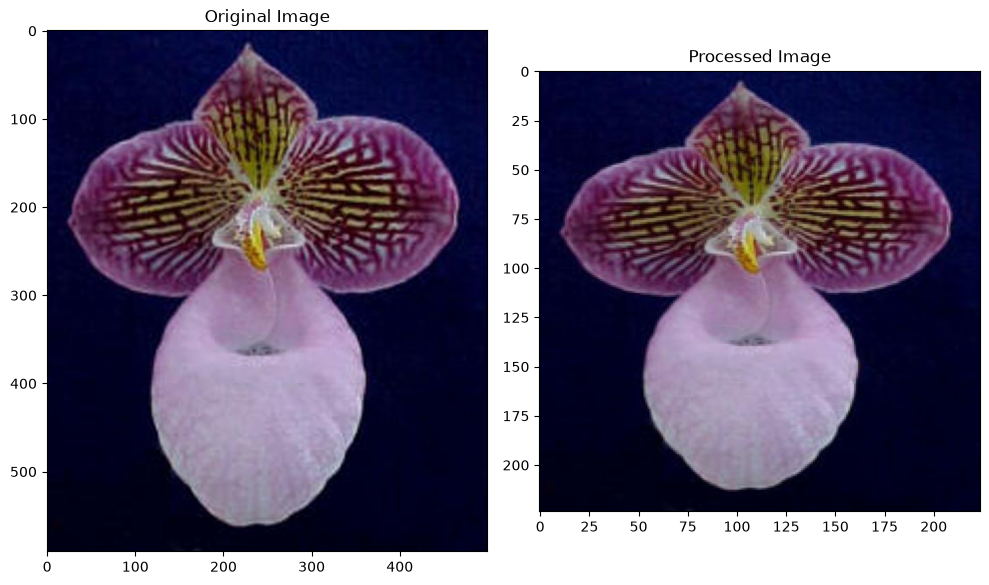

In [ ]:
from PIL import Image

image_path = './test_images/hard-leaved_pocket_orchid.jpg'
im = Image.open(image_path)
test_image = np.asarray(im)

processed_test_image = process_image(test_image)

fig, (ax1, ax2) = plt.subplots(figsize=(10,10), ncols=2)
ax1.imshow(test_image)
ax1.set_title('Original Image')
ax2.imshow(processed_test_image)
ax2.set_title('Processed Image')
plt.tight_layout()
plt.show()

In [ ]:
def predict(image_path, model, top_k=5):
    im = Image.open(image_path)
    
    test_image = np.asarray(im)
    
    processed_image = process_image(test_image)
    
    input_batch = np.expand_dims(processed_image, axis=0)
    predictions = model.predict(input_batch)
    
    probs, indices = tf.math.top_k(predictions, k=top_k)
    
    top_probs = probs.numpy()[0]
    top_classes = [str(idx) for idx in indices.numpy()[0]]
    
    return top_probs, top_classes

1/1 [==============================] - 0s 417ms/step


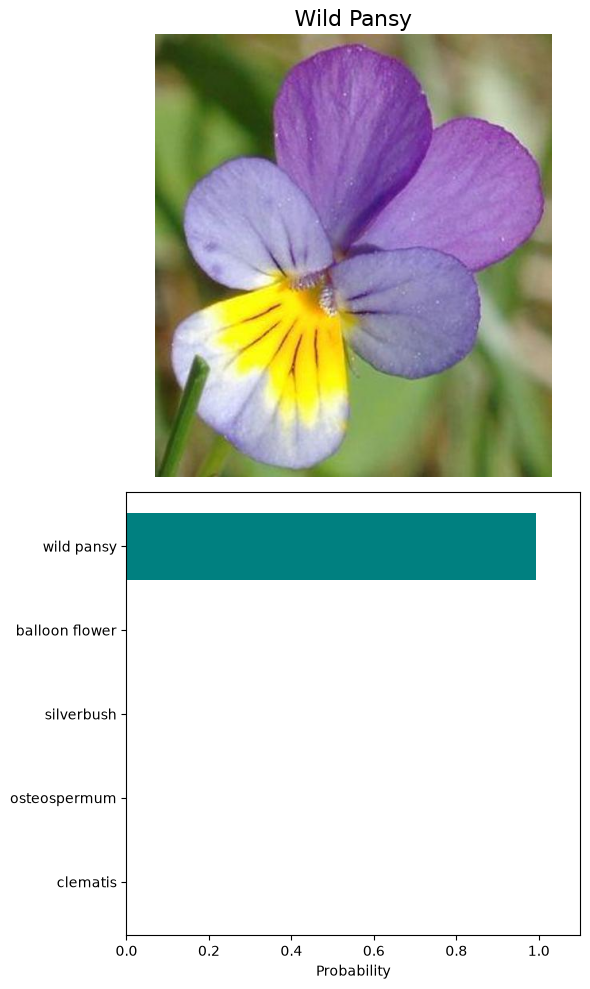

In [ ]:
image_path = './test_images/wild_pansy.jpg'

probs, classes = predict(image_path, reloaded_model, top_k=5)

names = [class_names[str(c)] for c in classes]

plt.figure(figsize=(6, 10))

ax1 = plt.subplot(2, 1, 1)
img = Image.open(image_path)
ax1.imshow(img)
ax1.axis('off')
ax1.set_title(names[0].title(), fontsize=16)


ax2 = plt.subplot(2, 1, 2)
ax2.barh(names, probs, color='teal')
ax2.invert_yaxis()
ax2.set_xlabel('Probability')
ax2.set_xlim(0, 1.1)

plt.tight_layout()
plt.show()